In [ ]:
#Kendi Value sınıfını yaz, toplama ve çarpma ile başla. Her yeni Value, kendisini üreten Value'ları ve hangi işlemden çıktığını saklasın. İstersen videodaki gibi computation graph'i graphviz ile çizdir. (19:09 - 32:10)

In [7]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data    # a = Value(2)  dediğimizde  a.data = 2 olur print(a.data) = 2 olur.
        self._prev = set(_children) # a = Value(2) dediğimizde print(a._prev)  çıktısı ise  set()  boş  b = Value(5) dediğimizde print(b._prev) çıktısı ise  set()  boş 
        #ancak  c = a + b dediğimizde print(c._prev) çıktısı ise  {a, b} olur. çünkü c nin çocuğu a ve b dir. a ve b nin ise ebebeyni yoktur.
        self._op = _op # operator +, *, - , / gibi işlemler için kullanılır. c = a + b dediğimizde c._op = '+' olur. c = a * b dediğimizde c._op = '*' olur. ancak a ve b nin _op si boş olur. çünkü onlar bir işlemden türetilmemiştir.

    def __repr__(self):
        return f"Value(data={self.data})"  # Bu fonksiyon olmasaydı <__main__.Value object at 0x7f8b2c0a1d90> gibi bir çıktı alacağımızdan yeniden tanımlanması sağlandı yeni çıktı Value(data=2) gibi bir çıktı alırız.
    
    def __add__(self, other):  #bu işlemde eğer value nesnesinde üretilmişse a = Value(2) , b=Value(3)  c = a + b dediğimizde 
        return Value(self.data + other.data, (self, other), '+')   # self.data + other.data  2 + 3 = 5  (self, other) ise  a, b dir + ise _op = '+'      c = Value(2 + 3, (a,b), '+')  
        #yani c.data = 5, c._prev =  {a,b} yani c._prev = {Value(2) + Value(3)} ise  c._op = '+'    yani c._prev demek c kimden geldi demek  arka planda  a.__add__(b) fonksiyonu çağırılır.

    def __mul__(self, other): 
        return Value(self.data * other.data, (self, other), '*') 

    def __sub__(self,other):
        return Value(self.data - other.data, (self, other), '-')

    def __truediv__(self, other):
        return Value(self.data / other.data, (self, other), '/')


In [33]:
# Bir örnek yapalım 
a = Value(2)
b = Value(3)
c = Value(7)
d = a + b * c
e = d / a
d

Value(data=23)

In [34]:
e
# Yukarıdaki işlemlerde sırasıyla Value(data=2, _prev=set(), _op='') ,Value(data=3, _prev=set(), _op='') , Value(data=7, _prev=set(), _op=''),  b.__mul__(c) çağırılır 
# burada self b other c oluyor ,  _prev = {b, c} ,  _op = '*'  Value(data=)
# t1= Value(data= 21 , _prev={a , b}, _op = '*') yani t1 =  Value(data=21, _prev={Value(data=3), Value(data=7)}, _op='*')
# d = a+ t1 olduğu için a__add__(t1) çağırılarak   d = Value(data = 2 + 21 = 23, _prev = {a, t1}, _op = '+')
# e = d / a oludğu için 
# e = d.__truediv__(a) e = Value(data=23,_prev = {d , a}, _op = '/') self d other a oluyor.
print('data',e.data)
print('previous',e._prev)
print('operation',e._op)

data 11.5
previous {Value(data=23), Value(data=2)}
operation /


In [35]:
print('data',d.data) 
print('previous',d._prev)
print('operation',d._op)

data 23
previous {Value(data=2), Value(data=21)}
operation +


In [36]:
print('data',e.data) 
print('previous',e._prev)
print('operation',e._op)

data 11.5
previous {Value(data=23), Value(data=2)}
operation /


In [25]:
print('data',c.data)
print('previous',c._prev)
print('operation',c._op)

data 7
previous set()
operation 


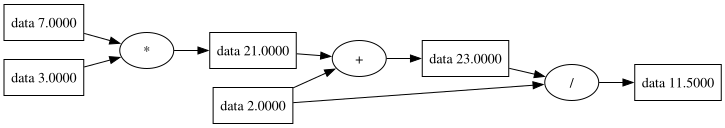

In [ ]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ data %.4f }" % (n.data,), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

draw_dot(e)